In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

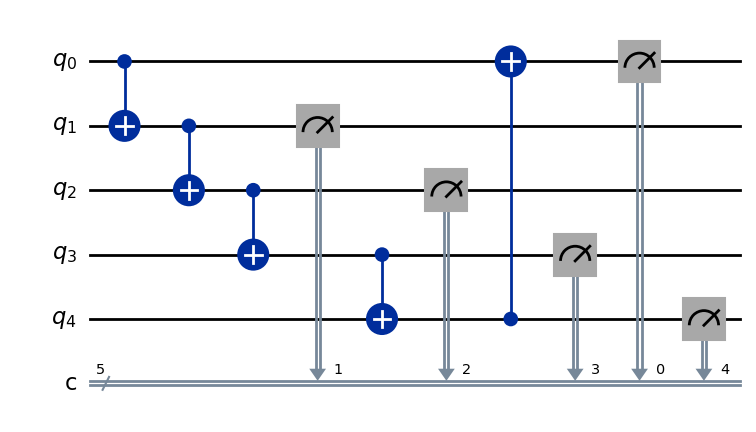

In [2]:
qc = QuantumCircuit(5, 5)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 0)
qc.measure([0, 1, 2, 3, 4], [0, 1, 2, 3, 4])
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [13]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [14]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "00000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.041796875
Errors for each run: [0.041015625, 0.0478515625, 0.029296875, 0.0517578125, 0.0380859375, 0.0419921875, 0.05078125, 0.04296875, 0.029296875, 0.0390625, 0.02734375, 0.033203125, 0.0400390625, 0.0419921875, 0.0361328125, 0.0380859375, 0.0380859375, 0.0498046875, 0.0498046875, 0.0498046875, 0.046875, 0.04296875, 0.044921875, 0.044921875, 0.041015625, 0.0458984375, 0.0439453125, 0.044921875, 0.0322265625, 0.0458984375, 0.0400390625, 0.0341796875, 0.037109375, 0.0439453125, 0.0498046875, 0.0478515625, 0.0478515625, 0.0439453125, 0.046875, 0.0400390625, 0.0517578125, 0.0419921875, 0.0537109375, 0.037109375, 0.037109375, 0.033203125, 0.03515625, 0.0390625, 0.0400390625, 0.0390625]


In [1]:
import numpy as np
errors = [0.041015625, 0.0478515625, 0.029296875, 0.0517578125, 0.0380859375, 0.0419921875, 0.05078125, 0.04296875, 0.029296875, 0.0390625, 0.02734375, 0.033203125, 0.0400390625, 0.0419921875, 0.0361328125, 0.0380859375, 0.0380859375, 0.0498046875, 0.0498046875, 0.0498046875, 0.046875, 0.04296875, 0.044921875, 0.044921875, 0.041015625, 0.0458984375, 0.0439453125, 0.044921875, 0.0322265625, 0.0458984375, 0.0400390625, 0.0341796875, 0.037109375, 0.0439453125, 0.0498046875, 0.0478515625, 0.0478515625, 0.0439453125, 0.046875, 0.0400390625, 0.0517578125, 0.0419921875, 0.0537109375, 0.037109375, 0.037109375, 0.033203125, 0.03515625, 0.0390625, 0.0400390625, 0.0390625]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.041796875
Standard deviation of errors over 50 runs: 0.0062561005382995956
0.0418 ± 0.0017 (95% CI)


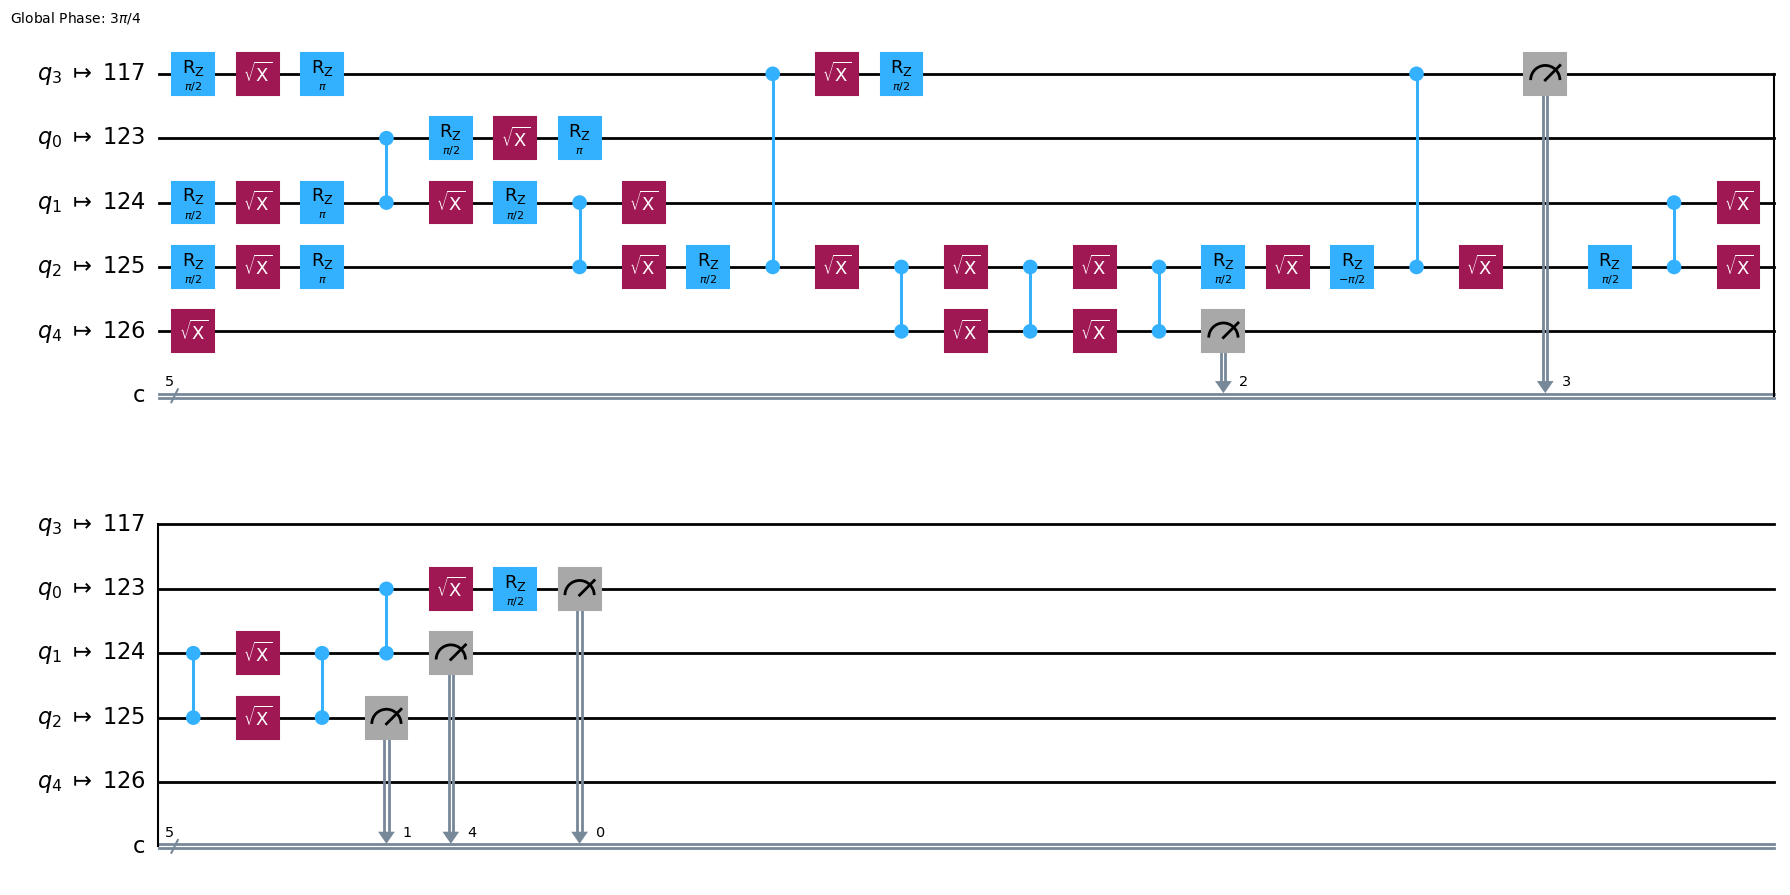

In [15]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [16]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "00000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.0463671875
Errors for each run: [0.052734375, 0.044921875, 0.05078125, 0.0400390625, 0.0546875, 0.0517578125, 0.0458984375, 0.0419921875, 0.0458984375, 0.0478515625, 0.0390625, 0.046875, 0.0400390625, 0.0439453125, 0.0458984375, 0.044921875, 0.05078125, 0.0380859375, 0.0615234375, 0.056640625, 0.0517578125, 0.0322265625, 0.048828125, 0.0517578125, 0.0517578125, 0.02734375, 0.048828125, 0.052734375, 0.0517578125, 0.048828125, 0.0439453125, 0.0439453125, 0.05078125, 0.041015625, 0.0498046875, 0.04296875, 0.029296875, 0.0419921875, 0.041015625, 0.0341796875, 0.0361328125, 0.0439453125, 0.0419921875, 0.0546875, 0.05078125, 0.05078125, 0.056640625, 0.0498046875, 0.048828125, 0.0556640625]


In [2]:
import numpy as np
errors = [0.052734375, 0.044921875, 0.05078125, 0.0400390625, 0.0546875, 0.0517578125, 0.0458984375, 0.0419921875, 0.0458984375, 0.0478515625, 0.0390625, 0.046875, 0.0400390625, 0.0439453125, 0.0458984375, 0.044921875, 0.05078125, 0.0380859375, 0.0615234375, 0.056640625, 0.0517578125, 0.0322265625, 0.048828125, 0.0517578125, 0.0517578125, 0.02734375, 0.048828125, 0.052734375, 0.0517578125, 0.048828125, 0.0439453125, 0.0439453125, 0.05078125, 0.041015625, 0.0498046875, 0.04296875, 0.029296875, 0.0419921875, 0.041015625, 0.0341796875, 0.0361328125, 0.0439453125, 0.0419921875, 0.0546875, 0.05078125, 0.05078125, 0.056640625, 0.0498046875, 0.048828125, 0.0556640625]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.0463671875
Standard deviation of errors over 50 runs: 0.007075166669304512
0.0464 ± 0.0020 (95% CI)


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [17]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_marrakesh 156 0
ibm_kingston 156 1


In [18]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [19]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7bobbm5nvhs73a3lpu0
Job ID: d7bobbrklj2c73evit30
Job ID: d7bobc65nvhs73a3lq00
Job ID: d7bobcbklj2c73evit50
Job ID: d7bobcjklj2c73evit5g
Job ID: d7bobch5a5qc73dnp97g
Job ID: d7bobcr0g7hs73dps3og
Job ID: d7bobd65nvhs73a3lq20
Job ID: d7bobd95a5qc73dnp990
Job ID: d7bobdjklj2c73evit80


In [20]:
job_ids = [
    "d7bobbm5nvhs73a3lpu0",
    "d7bobbrklj2c73evit30",
    "d7bobc65nvhs73a3lq00",
    "d7bobcbklj2c73evit50",
    "d7bobcjklj2c73evit5g",
    "d7bobch5a5qc73dnp97g",
    "d7bobcr0g7hs73dps3og",
    "d7bobd65nvhs73a3lq20",
    "d7bobd95a5qc73dnp990",
    "d7bobdjklj2c73evit80",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "00000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7bobbm5nvhs73a3lpu0: error = 0.0967
Job d7bobbrklj2c73evit30: error = 0.1123
Job d7bobc65nvhs73a3lq00: error = 0.1016
Job d7bobcbklj2c73evit50: error = 0.1016
Job d7bobcjklj2c73evit5g: error = 0.1025
Job d7bobch5a5qc73dnp97g: error = 0.0977
Job d7bobcr0g7hs73dps3og: error = 0.1143
Job d7bobd65nvhs73a3lq20: error = 0.1152
Job d7bobd95a5qc73dnp990: error = 0.1045
Job d7bobdjklj2c73evit80: error = 0.0889

Average error over runs: 0.103515625


Running on: ibm_fez (156 qubits)


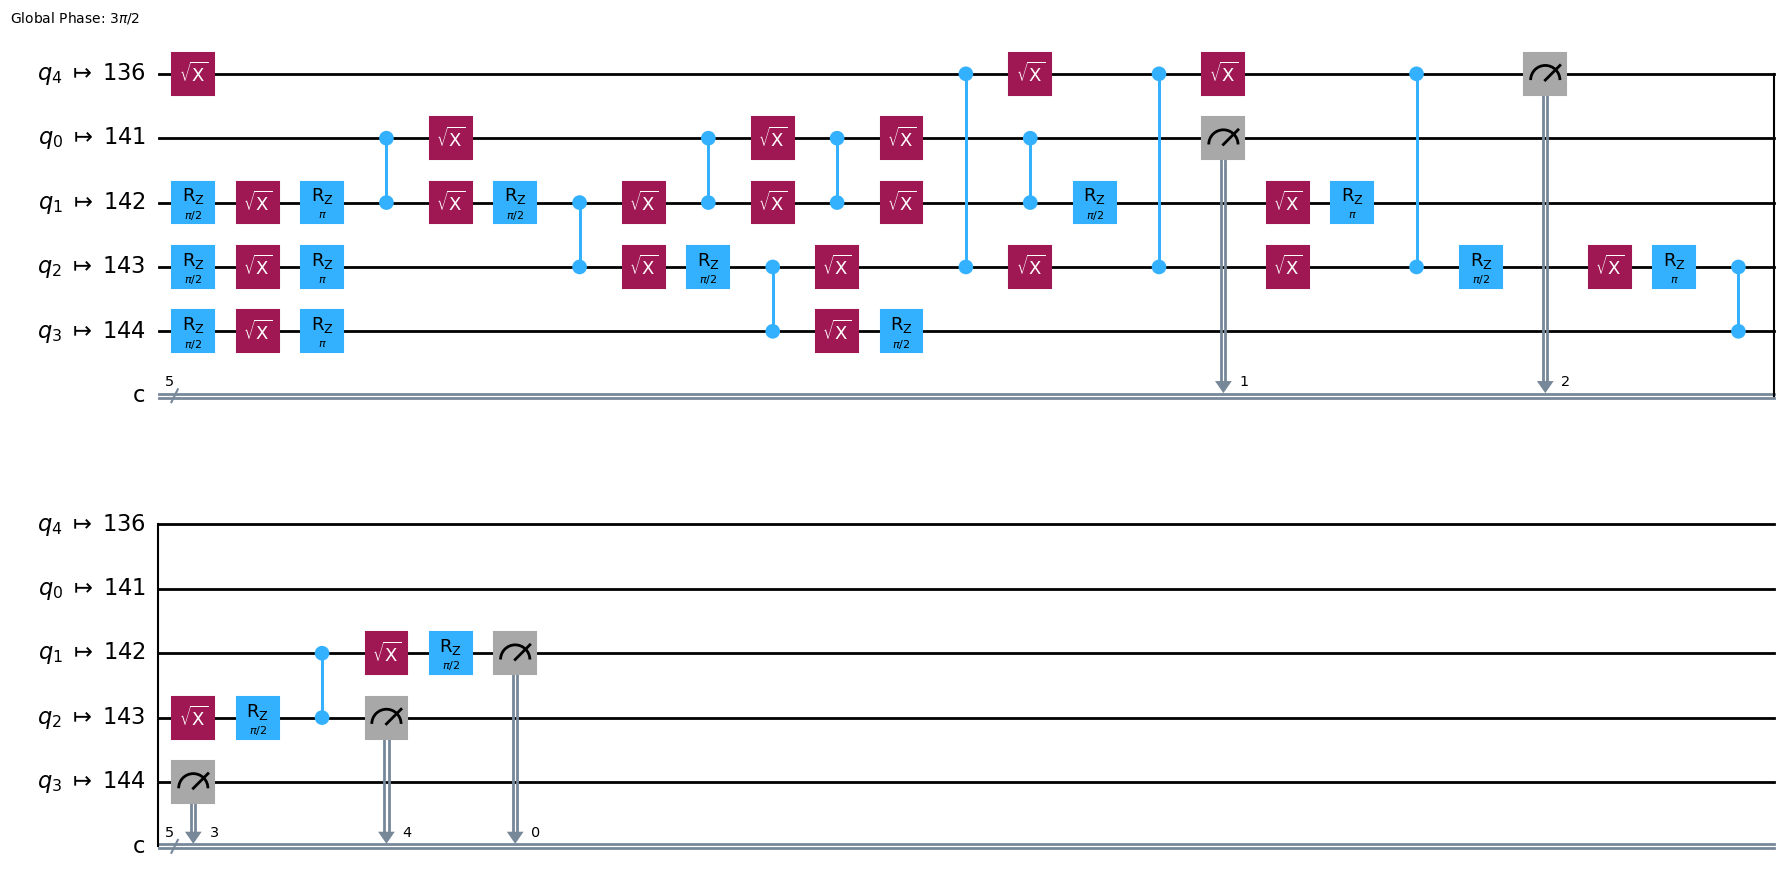

In [21]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")
# qc.draw("mpl")

In [22]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7boc1jklj2c73evitug
Job ID: d7boc1u5nvhs73a3lqt0
Job ID: d7boc265nvhs73a3lqtg
Job ID: d7boc2bklj2c73eviu00
Job ID: d7boc2m5nvhs73a3lqug
Job ID: d7boc2r0g7hs73dps4i0
Job ID: d7boc365nvhs73a3lqvg
Job ID: d7boc395a5qc73dnpa5g
Job ID: d7boc3jklj2c73eviu20
Job ID: d7boc3r0g7hs73dps4lg


In [23]:
job_ids = [
    "d7boc1jklj2c73evitug",
    "d7boc1u5nvhs73a3lqt0",
    "d7boc265nvhs73a3lqtg",
    "d7boc2bklj2c73eviu00",
    "d7boc2m5nvhs73a3lqug",
    "d7boc2r0g7hs73dps4i0",
    "d7boc365nvhs73a3lqvg",
    "d7boc395a5qc73dnpa5g",
    "d7boc3jklj2c73eviu20",
    "d7boc3r0g7hs73dps4lg",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "00000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7boc1jklj2c73evitug: error = 0.0830
Job d7boc1u5nvhs73a3lqt0: error = 0.0693
Job d7boc265nvhs73a3lqtg: error = 0.0664
Job d7boc2bklj2c73eviu00: error = 0.0684
Job d7boc2m5nvhs73a3lqug: error = 0.0850
Job d7boc2r0g7hs73dps4i0: error = 0.0732
Job d7boc365nvhs73a3lqvg: error = 0.0693
Job d7boc395a5qc73dnpa5g: error = 0.0723
Job d7boc3jklj2c73eviu20: error = 0.0547
Job d7boc3r0g7hs73dps4lg: error = 0.0645

Average error over runs: 0.07060546875


In [3]:
import time
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("Original circuit:")
print(f"No. of Gates: {qc.size()}")
print(f"Depth: {qc.depth()}\n")

print("My transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

from qiskit import transpile

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("\nQiskit transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:
No. of Gates: 10
Depth: 6

My transpiler:
No. of Gates: 103
Depth: 61
Transpilation time: 1.9958 seconds

Qiskit transpiler:
No. of Gates: 52
Depth: 31
Transpilation time: 0.0415 seconds


In [3]:
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

transpiled_circuit = transpile(qc, backend)

print("Original circuit:")

twoq = sum(1 for inst in qc.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in qc.data if len(inst.qubits) == 1)

print(f"\nOriginal circuit: {twoq} two-qubit gates, {oneq} single-qubit gates")

print("\nMy transpiler:")
twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)


print("\nQiskit transpiler:")

twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:

Original circuit: 5 two-qubit gates, 5 single-qubit gates

My transpiler:

 14 two-qubit gates, 89 single-qubit gates

Qiskit transpiler:

 11 two-qubit gates, 41 single-qubit gates
